# Matrix Methods in Data Mining and Pattern Recognition
U.G.I. 03.02.2026

## [Vectors](https://en.wikipedia.org/wiki/Vector_(mathematics_and_physics)),  [Matrices](https://en.wikipedia.org/wiki/Matrix_(mathematics)) and the [Julia Programming Language](https://julialang.org/) 
These notes demonstrates how the linear algebra basics required for MLA210/310 is represented in the [Julia Programming Language](https://julialang.org/) that you should [**install on your computer**](https://nmbu.instructure.com/courses/8659/pages/julia-installation-read-carefully-before-starting). 

**Also consult**
* the [VMLS coursebook for MLA210](https://web.stanford.edu/~boyd/vmls/) (_Introduction to Applied Linear Algebra – Vectors, Matrices, and Least Squares_)
* the [__Julia PC-installation description in Canvas__](https://nmbu.instructure.com/courses/8659/pages/julia-installation-read-carefully-before-starting)
* the VMLS [Julia language companion](https://web.stanford.edu/~boyd/vmls/vmls-julia-companion.pdf)
* [the useful Julia-slides](https://stanford.edu/class/engr108/julia.html) about specific topics related to both MLA210 and our course.


---
## Import and access essential Julia packages for Linear Algebra

In [294]:
# import Pkg; 
# Pkg.add(url="https://github.com/VMLS-book/VMLS.jl") # add the Julia-package for the VMLS book.
# Pkg.add("LinearAlgebra")                            # add the LinearAlgebra package

using VMLS
using LinearAlgebra

### Julia tutorial video
The below [Julia intoduction video](https://www.youtube.com/watch?v=8h8rQyEpiZA&t=16s) with [corresponding code on Github](https://github.com/JuliaAcademy/Introduction-to-Julia).

In [295]:
# Pkg.add("ShortCodes")
# For displaying Youtube videos...
# using ShortCodes
# YouTube("8h8rQyEpiZA",0,16)

**Same video -** [The tutorial section about basic linear algebra:](https://www.youtube.com/watch?v=8h8rQyEpiZA&t=7173s)

In [296]:
# using ShortCodes
# YouTube("8h8rQyEpiZA",120,7)

---
# Vectors
[**Vectors**](https://en.wikipedia.org/wiki/Vector_(mathematics_and_physics)) (vertically ordered lists of numbers) in Julia are represented by one-dimensional Array objects. A vector is constructed by giving the list of elements surrounded by square brackets, with the elements separated by commas or semicolons. The assignment operator (=) is used to give a name to the array. The `length` function returns the size (dimension).

In [297]:
x = [-1.1, 0.0, 3.9, -7.2] # Assignment using commas

4-element Vector{Float64}:
 -1.1
  0.0
  3.9
 -7.2

In [298]:
length(x) # The length (dimension) of vector x

4

In [299]:
y = [-1.1; 0.0; 3.9; -7.2] # Same assignment as above by using semicolons

4-element Vector{Float64}:
 -1.1
  0.0
  3.9
 -7.2

In [300]:
length(y)

4

The ```Vector{Float64,1}``` displayed by Julia above each array tells us that the vector entries are floating point numbers using 64 bits.

---

### __For your notice (some common mistakes)__
Don't forget the commas ``,`` or semicolons ``;`` between entries, and be sure to use square brackets `[]` and not ordinary parentheses. Otherwise you'll get other things that may make sense in Julia, but not as (vertical) vectors.

In [301]:
a = [ 1 2 ]     # A row vector (a horizontally ordered list of numbers)
b = ( 1, 2 )    # A tuple with two elements ( 1 and 2 )
c = a, b        # A tuple containing the two above elements ( a and b )

([1 2], (1, 2))

In [302]:
d,e = c[2]      # Values of the tuple in the second entry of the tuple c


(1, 2)

In [303]:
[d e] == c[1]   # Same as row vector a held in c[1]

true

Here `a` is a row vector, which we will encounter later; `b` is a [tuple](https://www.youtube.com/watch?v=J-9bGo-nNyE), i.e. a list consisting of two scalars. Finally `c` is another tuple listing `a` and `b`. 

---
## Indexing
A specific element $x_i$ of a vector $x$ is retrieved by the expression ```x[i]``` where ```i``` is the index (which runs to 1 to $n$, for an $n$-vector). Array indexing can also be used on the left-hand side of an assignment, to change the value of a specific vector element. 

In [304]:
x = [ -1.1, 0.0, 3.6, -7.2 ];
x[3] # The 3rd element of x

3.6

In [305]:
x[3] = 4.0 # The 3rd element of x is assigned (updated) to a new value (4.0)
x

4-element Vector{Float64}:
 -1.1
  0.0
  4.0
 -7.2

In [306]:
x[end] # Gives the last (n-th) entry of the n-dimensional vector x

-7.2

The special index `end` refers to the last index of a vector. In the example above, `x[end]` and `x[length(x)]` both give the last entry `-7.2`.

---

## Assignment versus copying:
If `x` is a vector or an array **this assignment only gives a new name (or reference)** `y` to the **same** vector or array already referenced by `x` (thus `x` and `y` share the same space in the Julia-memory). It __does not create a new copy__ of the content in `x`.

In [307]:
x = [ -1.1, 0.0, 3.6, -7.2 ];
y = x
x[3] = 4.0
y           # Shows the same memory content as x, i.e. the assignment to x[3] also changes y[3]

4-element Vector{Float64}:
 -1.1
  0.0
  4.0
 -7.2

In [308]:
y[1] = 2.0
x           # Shows the same memory content as y

4-element Vector{Float64}:
  2.0
  0.0
  4.0
 -7.2

#### Checking for identical objects (===)

In [309]:
y === x # By using === (see below) we ask if x and y are just different names of the same object (vector).

true

__Copying:__ We use the `copy`-function to create **a new copy** of a vector (or more generally of an array etc).

In [310]:
# Check out:
x = [ -1.1, 0.0, 3.6, -7.2 ];
y = copy(x) # Make a separate copy of x.
x == y, x === y # x and y are identical (== is true) but not the same (=== is false)

(true, false)

In [311]:
x[3] = 4.0
y, x # Changeing the 3rd entry of x does not affect y and vice versa

([-1.1, 0.0, 3.6, -7.2], [-1.1, 0.0, 4.0, -7.2])

In [312]:
y[1] = 2.0
x # As y is a separate copy, changing an entry in y will not affect the original x.

4-element Vector{Float64}:
 -1.1
  0.0
  4.0
 -7.2

**Vector equality - comparisons:** \
Equality of vectors is checked using the relational operator `==` for **comparing the content** of two ovjects. For vectors (arrays) `a` and `b`, the Julia expression `a == b` evaluates to `true` if the vectors (arrays) are equal, *i.e.*, they have the same length and identical entries, and `false` otherwise.

In [313]:
x = [ -1.1, 0.0, 3.6, -7.2 ];
y = copy(x)
y[3] = 4.0
y == x # As y is just a copy, y-updatings does not affect x

false

__Element-wise comparions:__ \
To do this, we use `.` in front of the `==` operator to compare entry-by-entry:

In [314]:
y.==x
# Results in a bit-vector where 1 indicate equality and 0 indicate inequality.

4-element BitVector:
 1
 1
 0
 1

In [315]:
# What is going on here?
z = x
z[3] = 4.0
z == x, z.== x, z === x

(true, Bool[1, 1, 1, 1], true)

---
## Scalars versus 1-vectors
In the mathematical notation used in VMLS we consider a 1-vector to be the same as a number. But in Julia, 1-vectors **are not the same** as scalars (numbers). 

**Therefore, note that** that Julia distinguishes between the 1-vector (array) `[ 1.3 ]` and the scalar `1.3`.

In [316]:
x = [1.3] # a 1-vector

1-element Vector{Float64}:
 1.3

In [317]:
y = 1.3   # a scalar

1.3

In [318]:
x == y    # false - these are not the same

false

In [319]:
x[1] == y # true - because x[1] (the first entry of x) is a scalar with the same value as y

true

In the last line, `x[1]` is the first (and only) entry of `x`, which is indeed contains the scalar (number) `1.3`.

---
## Stacking vectors
To concatenate vectors in Julia, you can use the function `vcat` (vertical concatenate) or the semicolon `;` operator within brackets `[` `]` to join two or several vectors together. Let's construct the block vector $z = (x,y)$ with $x = (1,-2)$ and $y = (1,1,0)$ using both methods and compare the results:

In [320]:
x = [1, -2]; y = [1, 1, 0];
z₁ = [x; y] # Concatenate using semicolon

5-element Vector{Int64}:
  1
 -2
  1
  1
  0

In [321]:
z₂ = vcat(x,y)

5-element Vector{Int64}:
  1
 -2
  1
  1
  0

In [322]:
z₁ == z₂

true

In [323]:
v = vcat(x, z₁, y) # Joining together more than 2 vectors works fine
w = [x; z₁; y]

10-element Vector{Int64}:
  1
 -2
  1
 -2
  1
  1
  0
  1
  1
  0

In [324]:
v == w # true - i.e. same result

true

As in mathematical notation, you can also stack vectors in between scalars, *e.g.*, ```[1;x;0]``` create (1,x,0) and vice versa.

In [325]:
vₛ = [1; x; 0]

4-element Vector{Int64}:
  1
  1
 -2
  0

---
## Vector of vectors
__Note:__ By replacing `;` (semi-colon) with `,` (comma) in the above expression we obatin a vector of vectors:

In [326]:
w₂ = [x, z₁, y]

3-element Vector{Vector{Int64}}:
 [1, -2]
 [1, -2, 1, 1, 0]
 [1, 1, 0]

**Warning - some common mistakes:** \
There are a few Julia operations that look similar but do not construct a block or stacked vector. For example: 
* `z = (x,y)` creates a list or tuple of the two vectors; 
* `z = [x,y]` creates an array of the two vectors. 

Both of these are valid Julia expressions, but neither of them is the stacked (concatenated) vector `[x; y]`.

In [327]:
z = (x,y)

([1, -2], [1, 1, 0])

In [328]:
z = [x,y]

2-element Vector{Vector{Int64}}:
 [1, -2]
 [1, 1, 0]

In [329]:
[x; y]

5-element Vector{Int64}:
  1
 -2
  1
  1
  0

---
## Subvectors and slicing
As in the mathematical notation used in [VMLS](https://web.stanford.edu/~boyd/vmls/), the Julia expression ```r:s``` denotes the index ranging from $r$ to $s$:  $r, r + 1,...,s$. (It is assumed here that `r` and `s` are positive integers with `r` the smaller of the two.) 

In [VMLS](https://web.stanford.edu/~boyd/vmls/) we use $x_{r:s}$ to denote the slice of the vector x from index r to s. In Julia you can extract a subvector or slice of a vector using an index range as the argument. You can also use index ranges to assign a slice of a vector.

In [330]:
x = [9,4,3,0,5]
y = x[2:4] # Slicing out the index entries from 2 to 4 of x.

3-element Vector{Int64}:
 4
 3
 0

In [331]:
#Re-assign the entries of slice 4 to 5 in x
x[4:5] = [-2, -3]; 
x

5-element Vector{Int64}:
  9
  4
  3
 -2
 -3

In [332]:
x[[2; 5]] # Slicing out the entries 2 and 5 from x

2-element Vector{Int64}:
  4
 -3

---
## Julia indexing into vectors (arrays)
Julia slicing and subjectoring is much more general than the mathematical notation we use in VMLS. For example, one can use a number range with a third argument, that gives the stride, which is the increment between successive indexes. For example, the index range ```1:2:5``` is the list of numbers ```1,3,5```. The expressiong ```x[1:2:5]``` extracts the 3-vector ```[9,3,-3]```, i.e., the first, third, and fifth entries of x defined above. You can also use an index range that runs backward. For any vector ```y```, the Julia expressiong ```y[end:-1:1]``` is the reversed vector, i.e., the vector with the same numbers, but in reverse order. 

In [333]:
x[1:2:5]

3-element Vector{Int64}:
  9
  3
 -3

In [334]:
y[end:-1:1], y


([0, 3, 4], [4, 3, 0])

---
## Vector of first differences
Let's use slicing to create the (n-1)-vector d defined by $d_i = x_{i+1} - x_i$ for $i = 1,...,n - 1$, where x is an n-vector. The vector d is called the vector of (first) differences of x.

In [335]:
x = [0, 1, -1, -4, -8];
d = x[2:end] - x[1:end-1]

4-element Vector{Int64}:
  1
 -2
 -3
 -4

Application of the `diff`-function results in the same:

In [336]:
diff(x)

4-element Vector{Int64}:
  1
 -2
 -3
 -4

---
## List of vectors
An ordered list of n-vectors might be denoted in VMLS as $a_1,...,a_k$ or $a^{(1)},...,a^{(k)}$ or just as $a,b,c$. There are several ways to represent lists of vectors in Julia. If we give the elements of the list, separated by commas, and surrounded by square brackets, we form a one-dimensional array of vectors. If instead we use parentheses as delimiters, we obtain a tuple, or list. 

In [337]:
x = [1.0, 0]; y = [1.0,-1.0]; z = [0,1.0];
A₁ = [x,y,z] # Vector of the vectors x, y and z

3-element Vector{Vector{Float64}}:
 [1.0, 0.0]
 [1.0, -1.0]
 [0.0, 1.0]

In [338]:
A₁[2] # Second element of A₁

2-element Vector{Float64}:
  1.0
 -1.0

In [339]:
L₂ = (x,y,z) # Tuple of the vectors x, y and z

([1.0, 0.0], [1.0, -1.0], [0.0, 1.0])

In [340]:
L₂[3] # Third element of list2

2-element Vector{Float64}:
 0.0
 1.0

In [341]:
# The third element of the array (list1) and of the tuple (list2) are both vectors, 
A₁[3]==L₂[3] # and they are equal in values!

true

In [342]:
A₁[3]===L₂[3] # ... and even identical copies (why?)

true

In [343]:
# The array (vector) of vectors and the list of the same vectors 
# are of different data types and therefor not identical:
A₁==L₂

false

In [344]:
# Element-wise comparison still shows identity between the corresponding entries of the two:
A₁.==L₂

3-element BitVector:
 1
 1
 1

---
Note the difference between `[x,y,z]` (an array of arrays) and `[x;y;z]` (an array of numbers, obtained by concatenation). 

To extract the i-th vector from the list of vectors, use `list[i]`. To get the j-th element or coefficient of the i-th vector in list1, use `list1[i][j]`.


In [345]:
A₁[2][1] == L₂[2][1] # The two scalars (numbers) we compare are identical

true

In [346]:
L₂[2]

2-element Vector{Float64}:
  1.0
 -1.0

---
## Zero vectors and standard basis vectors
In Julia a __zero vector__ of dimension (length) n is created using `zeros(n)`.

In [347]:
z₃ =  zeros(3)

3-element Vector{Float64}:
 0.0
 0.0
 0.0

The expression ```zeros(length(a))``` creates a vector with the same size as the vector ```a```.

**Unit vectors of the standard basis in $R^n$**: \
There is no built-in Julia function for creating $e_i$, the i-th unit vector of length n. The following code creates the n-vector $e_i$, for i = 2 and n = 4:

In [348]:
i = 2; n = 4;
eᵢ = zeros(n); # Create a zero vector of length n
eᵢ[i] = 1;     # Set i-th entry to 1
eᵢ

4-element Vector{Float64}:
 0.0
 1.0
 0.0
 0.0

In [349]:
eye(4)

4×4 Matrix{Float64}:
 1.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0
 0.0  0.0  1.0  0.0
 0.0  0.0  0.0  1.0

---
Here's another way to create a standard basis vector $e_i$ using concatenation, by using `unit_vector(i,n)` a so-called **Julia inline function**.

In [350]:
unit_vector(i,n) = [zeros(i-1); 1; zeros(n-i)] # inline function for defining unit vectors

unit_vector (generic function with 1 method)

In [351]:
 uᵢ = unit_vector(2,4) # The second standard basis vector in R⁴.

4-element Vector{Float64}:
 0.0
 1.0
 0.0
 0.0

In [352]:
eᵢ == uᵢ # the two vectors are equal

true

In [353]:
eᵢ === uᵢ # ... but not indentical

false

In [354]:
# Alternative definitions of eᵢ and uᵢ :
n = 4;
eᵢ = eye(n)[:,i]
uᵢ = Matrix{Float64}(I, n, n)[:,i]

4-element Vector{Float64}:
 0.0
 1.0
 0.0
 0.0

In [355]:
eᵢ == uᵢ, eᵢ === uᵢ # the two vectors are equal but not indentical

(true, false)

---
## Ones (constant) vector
In a similar fashion, the vector of ones with dimension $n$, denoted $\textbf1_n$ or just $\textbf1$ in VMLS, is created using the function `ones(n)`.

In [356]:
ones(2)

2-element Vector{Float64}:
 1.0
 1.0

---
## Random vectors
In VMLS, random vectors is not emphasized. However, it is sometimes useful to generate random vectors, for example to test an identity or some algorithm. In Julia, `rand(n)` generates a random vector of length $n$ with entries that are [uniformly random](https://en.wikipedia.org/wiki/Continuous_uniform_distribution) between 0 and 1. Each time this function is called or evaluated, it reeturns a different vector. 

The variant `randn(n)` (with the extra 'n' for normal) gives an n-vector with entries that come from a [normal (Gaussian) distribution](https://en.wikipedia.org/wiki/Normal_distribution). They can be positive or negative, with typical values on the order of one. 

Remember that every time you evaluate these functions, you get a different random vector. In particular, you will obtain different entries in the vectors below when you run the code.

In [357]:
rand(2)

2-element Vector{Float64}:
 0.5250299115758841
 0.1525725479804284

In [358]:
randn(10)

10-element Vector{Float64}:
 -0.14553856090094477
 -0.41029927442581754
 -0.16737592616952704
 -1.1784680445184492
 -1.8012079570026611
 -0.2610116542098464
 -1.0080457859440781
 -1.3028405078303087
  0.0036707061463276073
 -2.1630818358118673

---
## Plotting
There are several external packages for creating plots in Julia. One such package is **Plots.jl**, which you must add (install) via Julia's package manager control system; see page ix. Assuming the Plots package has been installed, you import it into Julia for use, using the command `using Plots`. (This can take some time.) After that you can access the Julia commands that create or manipulate plots. 

For example, we can plot the temperature time series in Figure 1.3 of VMLS using the code below; the last line saves the plot into a file `temperature.pdf`. The result is shown in Figure 1.1.

In [359]:
#import Pkg; Pkg.add("LaTeXStrings")
using Plots # Only need to do this once per session
using LaTeXStrings

In [360]:
temps = [71, 71, 68, 69, 68, 69, 68, 74, 77, 82, 85, 86, 88, 86, 85, 86, 84, 79, 77, 75, 73, 71, 70, 70, 69, 69, 69, 69, 67, 68, 68, 73, 76, 77, 82, 84, 84, 81, 80, 78, 79, 78, 73, 72, 70, 70, 68, 67];
length(temps)

48

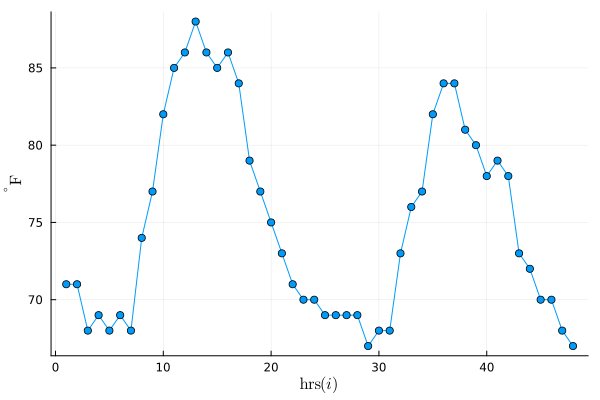

In [361]:
plot(temps, marker = :circle, legend = false, grid = true, xlabel=L"\textrm{hrs} (i)", ylabel = L"{^{\circ}}\textrm{F}")
# savefig("temperature.pdf")
# display(plot!())

**Figure 1.1** Hourly temperature in downtown Los Angeles on August 5 and 6, 2015 (starting at 12:47AM, ending at 11:47PM).

---
## V.2 Vector addition

**Vector addition and subtraction:**\
If `x` and `y` are vectors of the same size, `x+y` and `x-y` **overloads** the scalar versions into element-wise `+` (summation) and `-` (difference), respectively.

In [362]:
a = [0, 7, 3]; b = [1, 2, 0]; c = [6, 2, 9]; 
z = zeros(3); # Null-vector
a+b # Vector addition

3-element Vector{Int64}:
 1
 9
 3

In [363]:
a+b == b+a  # commutative property

true

In [364]:
(a+b)+c == a+(b+c) == a+b+c  # associative property

true

In [365]:
a+z == a  # Addition by z does not change anything

true

In [366]:
b-c         # Vector subtraction

3-element Vector{Int64}:
 -5
  0
 -9

---
## V.3 Scalar-vector multiplication

**Scalar-vector multiplication and division:**\
If ```a``` is a number and ```x``` a vector, you can express the scalar-vector product either as ```a*x``` or ```x*a```. (Julia actually allows you to write ```2.0x``` for ```2.0*x```. This is unambiguous because variable names cannot start with a number.) You can carry out scalar-vector division in a similar way, as ```x/a```, or the less familiar looking expression ```a\x```.

In [367]:
x = [0, 2, -1]
2.2*x, x*2.2  # Scalar-vector multiplication

([0.0, 4.4, -2.2], [0.0, 4.4, -2.2])

In [368]:
2.2x == 2.2*x == x*2.2  # Compare alternative Julia-notation for scaling vectors

true

In [369]:
x/3, 3\x  #Scalar-vector division

([0.0, 0.6666666666666666, -0.3333333333333333], [0.0, 0.6666666666666666, -0.3333333333333333])

In [370]:
x/3 == 3\x

true

**Scalar-vector addition and subtraction:** \
In Julia you can add a scalar `a` and a vector `x` using `x .+ a`. The dot (`.`) that precedes the plus symbol tells Julia to apply the operation element-wise (to each element - more on this below). The meaning is that the scalar is added or subtracted to each element. (This is not standard mathematical notation; in VMLS the corresponding notation is $x+a1$, where $x$ is an $n$-vector and $a$ is a scalar.) 

In Julia one can also carry out scalar-vector addition with the scalar on the left.

In [371]:
a = [1.1, -3.6, 0.1];
a .- 2.1  # Vector-scalar subtraction

3-element Vector{Float64}:
 -1.0
 -5.7
 -2.0

In [372]:
-2.1 .+ a # With the scalar on the left we obtain the same result

3-element Vector{Float64}:
 -1.0
 -5.7
 -2.0

---
## Element-wise operations
Julia supports methods for carrying out an operation on every element or coefficient of a vector. To do this we place a dot (`.`) before the operator, i.e. (`.*`,  `./`,  `.\`,  `.^`). 

For example, if x and y are vectors of the same length, then `x.*y, x./y, x.\y, x.^y` are elementwise vector-vector operations. They result in vectors of the same length as x and y, and $i$-th element $x_iy_i, x_i/y_i, y_i/x_i$, and ${x_i}^{y_i}$, respectively.

As an example of elementwise division, let's find the 3-vector of **asset returns** `r` from the (vectors of) **initial and final prices of assets** [(see page 22 in VMLS)](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=32).

In [373]:
p_initial = [ 22.15, 89.32, 56.77 ];
p_final = [ 23.05, 87.32, 57.12 ];
r = (p_final - p_initial) ./ p_initial

3-element Vector{Float64}:
  0.04063205417607233
 -0.02239140170174653
  0.006165228113440097

In [374]:
[2,3].^[3,4] == [2^3, 3^4]

true

**Elementwise operations with a scalar:** \
Elementwise operations work when one of the arguments is a scalar, in which case it is interpreted as the scalar times a ones vector ($1$) of the appropriate dimension. Scalar-vector addition, described above, is a special case of this. If `a` is a scalar and `x` is a vector then `x.^a` is a vector with ith element $x^a_i$, and `a.^x` is a vector with elements $a^{x_i}$. Like scalar-vector addition, the dot notation for elementwise operations is not standard mathematical notation and therefore not used in VMLS. 

We can also use the period notation with a function that has a name, to let Julia know that the function should be applied elementwise. In this case we add the period *after* the function name to indicate that it should be applied elementwise. For example, if `x` is a vector, we can form `sin.(x)` to apply the $sine$ function element-wise, i.e. to each element of `x`.

The equality test operator `==` (and other relational operators like `<`,`>=`) can be made to work elementwise by preceding it with a dot: `x == y` tells us whether or not `x` and `y` are the same vector; `x.==y` is a vector whose entries tell us whether the corresponding entries in `x` and `y` are the same. 

In [375]:
w = [1,2,2]; z = [1,2,3]
w == z, w .== z   # Here we (first) compare w and z as vectors, then (second) we compare w and z element-wise.

(false, Bool[1, 1, 0])

In [376]:
w .== 2

3-element BitVector:
 0
 1
 1

---
### __Useful__
You can combine this with Julia's slicing to extract the subvector of entries that satisfy some logical condition. For example ```x[abs.(x).>1]``` gives the subvector of ```x``` consisting of the entries in `x` that are larger than one in magnitude. 

In [377]:
x = [1.1, -.5, -1.5, 0.3] # Here the first and third entries of x have absolute values lager than 1

4-element Vector{Float64}:
  1.1
 -0.5
 -1.5
  0.3

In [378]:
abs.(x)

4-element Vector{Float64}:
 1.1
 0.5
 1.5
 0.3

In [379]:
abs.(x) .> 1

4-element BitVector:
 1
 0
 1
 0

In [380]:
x[abs.(x) .> 1]  # the entries of x larger than one in magnitude

2-element Vector{Float64}:
  1.1
 -1.5

In [381]:
ids = findall(abs.(x) .> 1) # Finds indices of the desired entries
x[ids]                       # The values of the desired entries 

2-element Vector{Float64}:
  1.1
 -1.5

---
### Dot-notation works with assignments too 
... allowing you to assign multiple entries of a vector to the same scalar value. 

For example:

In [382]:
x = rand(4)

4-element Vector{Float64}:
 0.14948482891480785
 0.3356589983166567
 0.7128128537798929
 0.4106989994996797

In [383]:
x[1:2] = [-1, 1]
x

4-element Vector{Float64}:
 -1.0
  1.0
  0.7128128537798929
  0.4106989994996797

In [384]:
x[2:3] .= 1.3
x

4-element Vector{Float64}:
 -1.0
  1.3
  1.3
  0.4106989994996797

In [385]:
x[[1, 3]] .= x[4] # What are we doing here?
x

4-element Vector{Float64}:
 0.4106989994996797
 1.3
 0.4106989994996797
 0.4106989994996797

In [386]:
x[1] = 6 # What happens here?
x

4-element Vector{Float64}:
 6.0
 1.3
 0.4106989994996797
 0.4106989994996797

---
## **Linear combinations and functions** 
You can form a **linear combination** of vectors in Julia using scalar-vector multiplications and addition.

In [387]:
a = [1, 2]; b = [ 3, 4] # the vectors
α = -0.5; β  = 1.5;     # the scalars (Note that Julia accepts both Greek letters and Norwegian letters like æ, ø, and å.)
c = α*a + β*b           # The linear combination

2-element Vector{Float64}:
 4.0
 5.0

To illustrate some additional Julia syntax, we create **a function** that takes a list of coefficients and a list of vectors as its arguments, and returns the linear combination. The lists can be represented by tuples or arrays. 

In [388]:
function lincomb(αs, vs) # αs is a vector (or list) of coefficients, vs is a corresponding array (or list) of vectors
    n = length(vs[1]) # Length of vectors
    a = zeros(n)
    for i = 1:length(vs)
        a = a + αs[i] * vs[i];
    end
    return a
end

lincomb (generic function with 1 method)

In [389]:
lincomb((-0.5, 1.5), ([1,2], [3,4])) # function arguments are lists

2-element Vector{Float64}:
 4.0
 5.0

In [390]:
lincomb([-0.5, 1.5], [[1,2], [3,4]]) # Functions arguments are arrays

2-element Vector{Float64}:
 4.0
 5.0

---
A more __compact definition__ of the `lincomb`-function is given as follows.

In [391]:
function lincomb(αs,vs) # αs is a vector (or list) of coefficients, vs is a corresponding array (or list) of vectors
    return sum(αs[i] * vs[i] for i = 1:length(vs))
end

lincomb (generic function with 1 method)

In [392]:
lincomb([-0.5,1.5], ([1,2], [3,4])) == lincomb((-0.5,1.5), [[1,2], [3,4]])

true

Alternatively, the `lincomb`-function can also be defined by an **inline** specification (in just one line):

In [393]:
lincomb(αs,vs) = sum(αs[i] * vs[i] for i = 1:length(vs))

lincomb (generic function with 1 method)

In [394]:
lincomb((-0.5,1.5), [[1,2], [3,4]])

2-element Vector{Float64}:
 4.0
 5.0

---
### **Checking algebraic properties** 
Let's check the **right distributive property** of linear combinations
$$\beta(a+b) = \beta a+\beta b,$$
which in general holds for any two n-vectors $a$ and $b$, and any scalar $\beta$. 

We'll do this for $n=3$, and randomly generated $a$, $b$, and $\beta$. (This computation does not show that the property always holds; it only shows that it holds for the particular choice of (random) vectors. But it's good to be skeptical and check identities with random arguments.) We use the `lincomb` function we just defined above. 

In [395]:
β = randn()
a = rand(3)
b = rand(3)

β,a,b

(-0.09107189498165076, [0.6775093749607868, 0.24172681806699192, 0.899779538391192], [0.06764383038273902, 0.10359294428910037, 0.346912779960715])

In [396]:
lhs = β*(a+b) # The left hand side

3-element Vector{Float64}:
 -0.06786251446228603
 -0.031448925132382635
 -0.11353863189137559

In [397]:
rhs = β*a + β*b # The right hand side

3-element Vector{Float64}:
 -0.06786251446228603
 -0.031448925132382635
 -0.11353863189137559

In [398]:
lhs == rhs # what happened here?

true

In [399]:
lhs ≈ rhs 

true

Check the **left distributive property** 
$$(\beta+\gamma)a = \beta a+\gamma a,$$
which holds for any n-vector $a$, and any scalars $\beta, \gamma$ in similar fashion:

In [400]:
β = randn()
γ = randn()
a = rand(3)

3-element Vector{Float64}:
 0.5770951775129883
 0.8316304490649424
 0.5040425490541067

In [401]:
lhs = (β+γ)*a # The left hand side

3-element Vector{Float64}:
 -0.5960636912069758
 -0.8589652703840311
 -0.5206098994091874

In [402]:
rhs = β*a + γ*a # The right hand side

3-element Vector{Float64}:
 -0.5960636912069759
 -0.858965270384031
 -0.5206098994091874

In [403]:
lhs == rhs # what happened here??

false

In [404]:
lhs ≈ rhs 

true

__NOTE:__ Although the two vectors lhs and rhs are displayed as the same, **they might not be exactly the same, due to very small round-off errors in the floating point computations**. 

When we check an identity using random numbers, we can expect that the left-hand and right-hand sides of the identity are not exactly the same, but very close to each other as verified by the _approxtimatly equal_ `≈` comparison.

---
## V.4 The inner product

The inner product of two n-vectors $x$ and $y$ is denoted as $x^Ty$ in VMLS, but $x^ty$ is also common notation. 

In Julia, the inner product of `x` and `y` is denoted as `x'*y` (`x'y` also works).

In [405]:
x = [-1, 2,  2];
y = [ 1, 0, -3];
x'*y  # Note that the simplified notation x'y works for calculating inner products in Julia.         

-7

In [406]:
(x'*y, y'*x)                          # Commutative property (x'*y == y'*x) always holds true.

(-7, -7)

In [407]:
γ = randn()
(γ*(x'y), (γ*x)'y,  x'*(γ*y))         # Distribution of scalar property

(-3.657820840731895, -3.657820840731895, -3.657820840731895)

In [408]:
z = [2, 3, 1];
((x+y)'z, x'z + y'z)                  # Distribution of vector property

(5, 5)

In [409]:
w = [2,3,5];
(x+y)'*(z+w), x'z + x'w + y'z + y'w   # Combined rules

(6, 6)

---
### You can get the **i-th entry** 
... $a_i$ from vector $a$ by taking the scalar product with $e_i$:

In [410]:
n = 7
a = rand(n)

7-element Vector{Float64}:
 0.7335596773270324
 0.09607709838083234
 0.5777312500014801
 0.652218178356387
 0.7555074921205333
 0.8055495133461363
 0.6533845538628784

In [411]:
i = 3
ei = unit_vector(i,n)
ai = ei'a  # The inner product.
ai == a[i]   # Compare result of inner product with the i-th entry.

true

**Summation** of vector-entries by taking the inner product with the ${\bf 1}$-vector:

In [412]:
o = ones(n);      # 1-vector of length n
sv = o'a          # summation from inner product
sv == sum(a)  # compare summation by inner product and by the sum-function in Julia

true

---
**Total school-age population** 

Suppose that the 100-vector ``x`` gives the age distribution of some population, with $x_i$ representing the number of people of age ```i-1```, for $i = 1,...100$ (ages between 0 and 99 years). 

The total number of people with age between 5 and 18 (inclusive) is therefore given by $x_6+x_7+...+x_{18}+x_{19}$. We can express this sum as $s^Tx$, where $s$ is the vector with entries 1 for ```i = 6,...,19``` and 0 otherwise. In Julia, this is expressed as

In [413]:
n = 100;
x_ages = [rand(40:70) for i = 1:n]; # Here we generate some (unrealistic) random population of ages between 0 and 99 yrs.

In [414]:
s      = [zeros(5); ones(14); zeros(81)]; n  = length(s);
school_age_pop = s'*x_ages

school_age_pop, school_age_pop == sum(x_ages[6:19]) # Compare with direct summation of the entries associated with school-age.

(798.0, true)

Clearly, the same answer is found by the expression `sum(x_ages[6:19])`, using the Julia function `sum`, which gives the sum of the entries of an input-vector. 

---
## Norm of a vector
[__Norms__](https://en.wikipedia.org/wiki/Norm_(mathematics)) are basically about measuring the “size” of a vector. The most common vector norms of some vector $x\in\mathbb{R}^n$ are
$$\|x\|_1 =\sum_{i=1}^n|x_i|, \text{ 1-norm},$$
$$\|x\|_2 =\sqrt{\sum_{i=1}^nx_i^2} = \sqrt{x^Tx}, \text{ Euclidean norm (2-norm)},$$
$$\|x\|_\infty =\max_{1\leq i \leq n}|x_i|, \text{ max-norm} $$

The [Euclidean _distance_](https://en.wikipedia.org/wiki/Euclidean_distance) between two vectors $x,y\in\mathbb{R}^n$ is

$$d(x,y) = \|x-y\|_2.$$

In machine learning applications it is quite common to use the cosine of the angle between two vectors $x,y\in\mathbb{R}^n$ as a [similarity measure](https://en.wikipedia.org/wiki/Cosine_similarity):

$$\cos \theta(x, y) = \frac{x^Ty}{\|x\|_2\|y\|_2}.$$

With this measure two vectors are considered to be close if the cosine-value is close to 1. Similarly, $x$
and $y$ are said to be orthogonal if the angle between them is $\pi/2$, i.e., $x^Ty = 0$.

In [415]:
# In Julia we compute the 2-norm of the above vector x as follows:
norm(x)


3.0

In [416]:
# The cosine between the above x and y:
y = [1,2,3,4];
cosθ = x'y/(norm(x)*norm(y))

DimensionMismatch: DimensionMismatch: first array has length 3 which does not match the length of the second, 4.

In [417]:
# The angle θ (in radians)
θ = acos(cosθ)

1.1023521400609815

In [418]:
# The angle in degrees:
D₀ = round(θ*180/π, digits =3)

63.16

---
## V.5 Complexity of vector computations
[**Floating point operations (flops)**](https://en.wikipedia.org/wiki/FLOPS). For any two numbers $a$ and $b$, we have 

$$(a+b)(a-b) = a^2-ab+ab-b^2 = a^2-b^2.$$

When a computer calculates the left-hand and right-hand side, for specific numbers $a$ and $b$, they need not be exactly the same, due to very small roud-off errors due to the [floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic#:~:text=This%20is%20a%20binary%20format,(about%207%20decimal%20digits)) of digital computers. But they should be very nearly the same. Let's see an example of this. 

In [419]:
a = rand(); b = rand();
lhs = (a+b) * (a-b)

-0.07948862588882216

In [420]:
nhs = a^2 - a*b + a*b - b^2 #The expression in the middle should be identical to the rhs

-0.07948862588882216

In [421]:
rhs = a^2 - b^2

-0.07948862588882216

In [422]:
lhs-rhs # The difference can be non-zero but small due to very small floating point roud-off errors in the two caclulations.

0.0

In [423]:
lhs ≈ rhs # ≈ compares if lhs and rhs are equal within machine precision floating point arithmetic

true

Here, the left- and right-hand sides may not exactly equal, but very close. [in this case they're equal but if we increased precision by ~2 decimal places we would see slight inequality]

---
### Complexity: 
You can time a Julia command by adding ```@time``` before the command. The timer is not very accurate for very small times, say, measured in microseconds $(10^{-6} seconds)$. Also, you should run the command more than once; it can be a lot faster on the second of subsequent runs. 

In [424]:
@time lhs = (a+b) * (a-b) # 3 flops

  0.000011 seconds (3 allocations: 48 bytes)


-0.07948862588882216

In [425]:
@time nhs = a^2 - a*b + a*b - b^2 # 7 flops

  0.000029 seconds (7 allocations: 112 bytes)


-0.07948862588882216

In [426]:
@time rhs = a^2 - b^2 # 3 flops

  0.000008 seconds (3 allocations: 48 bytes)


-0.07948862588882216

---
### Inner product computations

In [427]:
a = randn(10^5); b = randn(10^5) 

@time a'*b # 2*10^5 flops

  0.000069 seconds (2 allocations: 32 bytes)


-411.95788543622086

In [428]:
@time a'*b

  0.000094 seconds (2 allocations: 32 bytes)


-411.95788543622086

In [429]:
c = randn(10^6); d = randn(10^6)
@time c'*d # 2*10^6 flops

  0.000375 seconds (2 allocations: 32 bytes)


794.0668481314384

The first inner product, of a vector of length $10^5$, takes around $0.0003$ seconds; the second, with vectors of length $10^6$ (ten times bigger), product takes around $0.0007$ seconds, about $2$ times longer. This is predicted by complexity of the inner product, which is $2n-1$ flops. The computer on which the computations were done is capable of around $2\times10^6/0.001765$ flops per second, i.e., around $1$ Gflop/s. These timings, and the estimate of the computer speed, are very approximate. 

---
### [Sparse vectors and arrays: ](https://en.wikipedia.org/wiki/Sparse_matrix)
Sparse vectors are large vectors containing a lot of $0$'s. To improve the computational efficiency when manipulating such vectors we can use the **[sparse](https://en.wikipedia.org/wiki/Sparse_matrix)** format. 

Functions for creating and manipulating sparse vectors are contained in the Julia package **SparseArrays**, so you need to install this package before you can use them; see pages [**ix-x** in the VMLS Julia Language companion](https://web.stanford.edu/~boyd/vmls/vmls-julia-companion.pdf).

Spare vectors are stored as [sparse arrays](https://en.wikipedia.org/wiki/Sparse_matrix), i.e., arrays in which only the nonzero elements are stored. In Julia you can create a sparse vector from lists of the indices and values using the `sparsevec` function. Alternatively, you can first create a sparse vector of zeros (using the function `spzeros(n)`) and then assign values to the nonzero entries. A sparse vector can be created from a non-sparse vector using the function `sparse(x)`, which returns a sparse version of `x`. The function `nnz(x)` counts the number of nonzero elmeents of a sparse vector. Sparse vectors are overloaded to work as you imagine; for example, all the usual vector operations work, and they are automatically recast as non-sparse vectors when appropriate. 

In [430]:
using SparseArrays  # Please refer to installation instructions in the vmls-julia-companion.pdf 

In [431]:
a = sparsevec([123456, 123457],[1.0,-1.0], 10^6) # A one million length vector with two non-zero entries.

1000000-element SparseVector{Float64, Int64} with 2 stored entries:
  [123456]  =  1.0
  [123457]  =  -1.0

In [432]:
length(a)

1000000

In [433]:
nnz(a) # The number of non-zero elements in a

2

In [434]:
b = randn(10^6); #An ordinary (non-sparse vector)

In [435]:
@time 2*a #Computed efficiently!

  0.000016 seconds (5 allocations: 192 bytes)


1000000-element SparseVector{Float64, Int64} with 2 stored entries:
  [123456]  =  2.0
  [123457]  =  -2.0

In [436]:
@time 2*b

  0.002440 seconds (3 allocations: 7.629 MiB)


1000000-element Vector{Float64}:
  0.8657955361412717
  3.0477289079290606
  3.2791107747779673
 -0.3384761406380778
  1.534050026904201
 -0.796255976016261
  3.599808563411903
  1.6713144002289877
 -1.5526691833015818
 -0.7596288398472644
  ⋮
 -0.064076312147385
  0.030853218011380062
  3.5936333053554304
  1.0925392015491615
  1.3934900631469467
  0.74888454314886
 -1.9309454196913804
 -1.482328697470798
 -0.08811432268425937

In [437]:
@time a'*b

-0.6889340228645615

  0.000014 seconds (2 allocations: 48 bytes)


In [438]:
@time b'*b

  0.000267 seconds (2 allocations: 32 bytes)


1.0003097810716225e6

In [439]:
@time c = a + b

  0.014415 seconds (25 allocations: 43.870 MiB)


1000000-element SparseVector{Float64, Int64} with 1000000 stored entries:
  [1      ]  =  0.432898
  [2      ]  =  1.52386
  [3      ]  =  1.63956
  [4      ]  =  -0.169238
  [5      ]  =  0.767025
  [6      ]  =  -0.398128
  [7      ]  =  1.7999
             ⋮
  [999993 ]  =  0.0154266
  [999994 ]  =  1.79682
  [999995 ]  =  0.54627
  [999996 ]  =  0.696745
  [999997 ]  =  0.374442
  [999998 ]  =  -0.965473
  [999999 ]  =  -0.741164
  [1000000]  =  -0.0440572

In [440]:
issparse(c)

true

In [441]:
c = Array(c) # Here we convert the sparse vector (c) to a dense (ordinary) vector.

1000000-element Vector{Float64}:
  0.43289776807063585
  1.5238644539645303
  1.6395553873889837
 -0.1692380703190389
  0.7670250134521005
 -0.3981279880081305
  1.7999042817059514
  0.8356572001144938
 -0.7763345916507909
 -0.3798144199236322
  ⋮
 -0.0320381560736925
  0.015426609005690031
  1.7968166526777152
  0.5462696007745808
  0.6967450315734733
  0.37444227157443
 -0.9654727098456902
 -0.741164348735399
 -0.04405716134212968

In [442]:
issparse(c)

false

Right above, the sparse vector c is automatically converted to an ordinary vector (array) of length $10^6$. 

---
# [Matrices](https://en.wikipedia.org/wiki/Matrix_(mathematics))

**Creating matrices from the entries.** Matrices are represented in Julia as $2$-dimensional arrays. These are constructed by giving the elements in each row, separated by space, with the rows separated by semicolons. For example, the $3 × 4$ matrix

$$
A = \begin{bmatrix}
 0 & 1 & −2.3 & 0.1\\
 1.3 & 4.0 & −0.1 & 0\\
 4.1 & −1.0 & 0 & 1.7
\end{bmatrix}
$$
is constructed in Julia as

In [443]:
A = [0.0 1.0 -2.3 0.1;
    1.3 4.0 -0.1 0.0;
    4.1 -1.0 0.0 1.7]

3×4 Matrix{Float64}:
 0.0   1.0  -2.3  0.1
 1.3   4.0  -0.1  0.0
 4.1  -1.0   0.0  1.7

(Here, `Array{Float64,2}` above the array tells us that the array is $2$-dimensional, and its entries are `64-bit` floating-point numbers.) Above, we have put the different rows of the matrix on different lines separated by`;` and line shifts to make the code more readable. However, it is not required to do the line shifts. The same matrix is obtained by the assignment

In [444]:
A = [0 1 -2.3 0.1; 1.3 4 -0.1 0; 4.1 -1 0 1.7]

3×4 Matrix{Float64}:
 0.0   1.0  -2.3  0.1
 1.3   4.0  -0.1  0.0
 4.1  -1.0   0.0  1.7

The Julia function `size(A)` gives the size, as a tuple. It can also be called as `size(A,1)` or `size(A,2)` to get only the number of rows and columns of `A`, respectively. 

In [445]:
m, n = size(A)

(3, 4)

In [446]:
n

4

In [447]:
m,n = size(A,1), size(A,2)

(3, 4)

In [448]:
m

3

---
### Tall matrices
As an example, lets create a function `tall` to determine if a matrix is __tall__ (i.e. if it has more rows than columns):

In [449]:
tall(X) = size(X,1) > size(X,2);
tall(A)

false

In the function definition, the number of rows and the number of columns are combined using the relational operator `<`, which gives a $Boolean$ value ('true' or 'false').

-----------------------


### Indexing entries
We get the $i, j$ entry of a matrix `A` using `A[i,j]`. We can also assign a new value to an entry.

In [450]:
A[2,3] # Get the 2,3 entry of A

-0.1

In [451]:
A[1,3] = 7.5; # Set 1,3 entry of A to the new value 7.5
A

3×4 Matrix{Float64}:
 0.0   1.0   7.5  0.1
 1.3   4.0  -0.1  0.0
 4.1  -1.0   0.0  1.7

---
**Single index indexing.** Julia allows you to access an entry of a matrix using only one index. To use this, you need to know that matrices in Julia are stored in column-major order. 

In [452]:
Z = [ -1 1 3; 0 2 4];
Z[:]

6-element Vector{Int64}:
 -1
  0
  1
  2
  3
  4

This means that a matrix can be considered as a one - dimensional array, with the first column stacked on top of the second, stacked on top of the third, and so on. For example, the elements of the matrix
$$
Z =
\begin{bmatrix}
−1 & 1 & 3\\
0 & 2 & 4
\end{bmatrix}
$$
are stored in the order
$$−1, 0, 1, 2, 3, 4.$$
With single index indexing, `Z[5]` is the fifth element in this sequence.

In [453]:

Z[5]

3

This is not at all standard linear algebra notation, and we would never use this in the (VMLS) matehmatical notation. But it can be handy in some cases when you are using Julia. 

---
### Equality of matrices 
`A == B` determines whether the matrices `A` and `B` are equal. The expression `A .== B` creates a matrix whose entries are $Boolean$, depending on whether the corresponding entries of `A` and `B` are the same. The expression `sum(A .== B)` gives the number of entries of `A` and `B` that are equal (**Note:** The two matrices A and B must have the same size).

In [454]:
B = copy(A); # B is a new matrix set to be a copy of A.
A == B

true

In [455]:
B[2,2] = 0; # We change one entry of A
A == B

false

In [456]:
A .== B

3×4 BitMatrix:
 1  1  1  1
 1  0  1  1
 1  1  1  1

In [457]:
sum(A .== B) # The number of equal entries when comparing A and B.

11

**Row and column vectors.** In Julia, as in VMLS, $n$-vectors are the same as $n × 1$ matrices.

In [458]:
a = [ -2.1 -3 0 ] # A 3-row vector or 1x3 matrix

1×3 Matrix{Float64}:
 -2.1  -3.0  0.0

In [459]:
b = [ -2.1; -3; 0 ] # A 3-vector or 3x1 matrix

3-element Vector{Float64}:
 -2.1
 -3.0
  0.0

The output reveals a small subtlety that generally won’t affect you. You can see that b has type `Array{Float64,1}`. The final `1` means that it is a $1D$ array; `size(b)` gives `(3,)`, whereas you might think it would or should be `(3,1)`. So you might say that in Julia, $n × 1$ matrices are n-vectors. This is why we say above that n-vectors and $n × 1$ matrices are almost the same in Julia. 

**Slicing and submatrices.** Using colon notation you can extract a submatrix.

In [460]:
A = [ -1 0 1 0 ; 2 -3 0 1 ; 0 4 -2 1]

3×4 Matrix{Int64}:
 -1   0   1  0
  2  -3   0  1
  0   4  -2  1

In [461]:
A[1:2,3:4]

2×2 Matrix{Int64}:
 1  0
 0  1

This is very similar to the mathematical notation in VMLS, where this submatrix would be denoted $A_{1:2,3:4}$. You can also assign a submatrix using slicing (index range) notation. A very useful shortcut is the index range `:` which refers to the whole index range for that index. This can be used to extract the rows and columns of a matrix.

In [462]:
A[:,3] # Third column of A

3-element Vector{Int64}:
  1
  0
 -2

In [463]:
A[2,:] # Second row of A, returned as column vector!

4-element Vector{Int64}:
  2
 -3
  0
  1

In mathematical (VMLS) notation, we say that `A[2,:]` returns the transpose of the second row of `A`. As with vectors, Julia’s slicing and selection is not limited to contiguous ranges of indexes. For example, we can reverse the order of the rows of a matrix `X` using

In [464]:
X = copy(A) #For example
m = size(X,1)
X[m:-1:1,:] # Matrix X with row order reversed

3×4 Matrix{Int64}:
  0   4  -2  1
  2  -3   0  1
 -1   0   1  0

Julia’s single indexing for matrices can be used with index ranges or sets. For example if $X$ is an $m × n$ matrix, `X[:]` is a vector of size $mn$ that consists of the columns of `X` stacked on top of each other. The Julia function `reshape(X,(k,l))` gives a new $k × l$ matrix, with the entries taken in the column-major order from `X`. (We must have $mn = kl$, i.e., the original and reshaped matrix must have the same number of entries.) Neither of these is standard mathematical notation, but they can be useful in Julia.

In [465]:
B = [ 1 -3 ; 2 0 ; 1 -2]

3×2 Matrix{Int64}:
 1  -3
 2   0
 1  -2

In [466]:
B[:]

6-element Vector{Int64}:
  1
  2
  1
 -3
  0
 -2

In [467]:
reshape(B,(2,3))

2×3 Matrix{Int64}:
 1   1   0
 2  -3  -2

In [468]:
reshape(B,(3,2))

3×2 Matrix{Int64}:
 1  -3
 2   0
 1  -2

---
### Block matrices
Block matrices are constructed in Julia very much as in the standard mathematical notation in VMLS. You use `;` to stack matrices, and a `space` to do (horizontal) concatenation. We apply this to the example on page [109](https://web.stanford.edu/~boyd/vmls/vmls.pdf#equation.6.1.1) of VMLS.

In [469]:
B = [ 0 2 3 ]; # 1x3 matrix

C = [ -1 ]; # 1x1 matrix

D = [ 2 2 1 ; 1 3 5]; # 2x3 matrix

E = [4 ; 4 ]; # 2x1 matrix

# construct 3x4 block matrix

A = [B C ; 
    D E]

3×4 Matrix{Int64}:
 0  2  3  -1
 2  2  1   4
 1  3  5   4

**Column and row interpretation of a matrix.** An $m × n$ matrix $A$ can be interpreted as a collection of $n$ $m$-vectors (its columns) or a collection of $m$ row vectors (its rows). Julia distinguishes between a matrix (a two-dimensional array) and an array of vectors. An array (or a tuple) of column vectors can be converted into a matrix using the horizontal concatenation function `hcat`.

In [470]:
a = [ [1., 2.], [4., 5.], [7., 8.] ] # array of 2-vectors

3-element Vector{Vector{Float64}}:
 [1.0, 2.0]
 [4.0, 5.0]
 [7.0, 8.0]

In [471]:
A = hcat(a...)

2×3 Matrix{Float64}:
 1.0  4.0  7.0
 2.0  5.0  8.0

The `...` operator in `hcat(a...)` splits the array `a` into its elements, i.e., `hcat(a...)` is the same as `hcat(a[1], a[2], a[3])`, which concatenates `a[1], a[2], a[3]` horizontally. Similarly, `vcat` concatenates an array of arrays vertically. This is useful when constructing a matrix from its row vectors.

In [472]:
a = [ [1. 2.], [4. 5.], [7. 8.] ] # array of 1x2 matrices

3-element Vector{Matrix{Float64}}:
 [1.0 2.0]
 [4.0 5.0]
 [7.0 8.0]

In [473]:
A = vcat(a...)

3×2 Matrix{Float64}:
 1.0  2.0
 4.0  5.0
 7.0  8.0

---
### How to convert an array of vectors into a matrix
In [**VMLS chapter 4**](https://web.stanford.edu/~boyd/vmls/vmls-julia-companion.pdf#page=44) we generated an array of vectors to illustrate clustering of a pont cloud (with 3 clusters) as follows:

In [474]:
# An array of 300 2d-vectors: 
X = vcat( [ 0.3*randn(2) for i = 1:100 ],
[ [1,1] + 0.3*randn(2) for i = 1:100 ],
[ [1,-1] + 0.3*randn(2) for i = 1:100 ] )

N,d = length(X),length(X[1])

(300, 2)

In [475]:
X

300-element Vector{Vector{Float64}}:
 [-0.14660503042692563, -0.09486314121436748]
 [0.4615733945490105, -0.2947263404369071]
 [0.1745981898747559, 0.1083871867997787]
 [0.01833851819898082, -0.05336104471849046]
 [-0.405495193132223, -0.7128788812212877]
 [-0.18733356486284197, -0.08968733070081243]
 [0.06656005309629205, -0.2567442625124957]
 [-0.4050643260377052, 0.3898882204890704]
 [-0.11454975475651437, -0.0023598173012840725]
 [-0.2219391472271345, 0.13373754162215648]
 ⋮
 [0.9911878826003991, -1.0801406866325942]
 [0.7857365263681579, -0.961762228056991]
 [1.10744508138858, -0.5861148128033625]
 [0.8206449456080259, -0.8915191201519032]
 [1.1461296246710928, -1.0677375118356416]
 [1.4490588396310176, -0.552448474594545]
 [1.3508527634785548, -0.5607943498519803]
 [1.4158740261645184, -0.7512673050929024]
 [1.2935249554047807, -1.5265787812043752]

__Conversion__ of `X` into a matrix with `d` rows and `N` columns is obtained by following function:

In [476]:
function arrayOfVectors2matrix(X)
N,d = length(X),length(X[1])
    Z = zeros(d,N) # a (d x N)-matrix of zeros (see below)
for k = 1:N
    Z[:,k] = X[k]; # Vectors of X become matrix columns
end
return Z;
end

Z = arrayOfVectors2matrix(X)

2×300 Matrix{Float64}:
 -0.146605    0.461573  0.174598  …   1.35085    1.41587    1.29352
 -0.0948631  -0.294726  0.108387     -0.560794  -0.751267  -1.52658

... or simply by using the `stack`-function:

In [477]:
stack(X)

2×300 Matrix{Float64}:
 -0.146605    0.461573  0.174598  …   1.35085    1.41587    1.29352
 -0.0948631  -0.294726  0.108387     -0.560794  -0.751267  -1.52658

---
### M.2 Zero and identity matrices
### Zero matrices 
A zero matrix of size (m × n) can be created using `zeros(m,n)`.

In [478]:
zeros(2,2)

2×2 Matrix{Float64}:
 0.0  0.0
 0.0  0.0

### Identity matrices
Identity matrices in Julia can be created various ways, for example by starting with a zero matrix and then setting the diagonal entries to one.

The `LinearAlgebra` package also contains functions for creating a special [**identity matrix object** `I`](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#The-uniform-scaling-operator), which has some nice features. You can use `1.0*Matrix(I,n,n)` to create an `n× n` identity matrix. (Multiplying by $1.0$ converts the matrix into one with numerical entries; otherwise it has $Boolean$ entries.) 

This expression is pretty unwieldy, so we define a function `eye(n)` to generate an identity matrix. This function is in the `VMLS` package, so you can use it once the package is installed. (The name `eye` to denote the identity matrix `I` traces back to the [**`MATLAB`** language](https://en.wikipedia.org/wiki/MATLAB).)

In [479]:
# A replica of the VMLS eye-function (called Eye) for demonstration:
Eye(n) = 1.0*Matrix(I,n,n)
Eye(4)

4×4 Matrix{Float64}:
 1.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0
 0.0  0.0  1.0  0.0
 0.0  0.0  0.0  1.0

In [480]:
eye(4)

4×4 Matrix{Float64}:
 1.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0
 0.0  0.0  1.0  0.0
 0.0  0.0  0.0  1.0

---
### Julia’s identity matrix `I` 
... has some useful properties. For example, when it can deduce its dimensions, you don’t have to specify it. (This is the same as with common mathematical notation; see [VMLS page 113](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=113).

In [481]:
A = [ 1 -1 2; 0 3 -1]

2×3 Matrix{Int64}:
 1  -1   2
 0   3  -1

In [482]:
[A I] # append identity matrix after A

2×5 Matrix{Int64}:
 1  -1   2  1  0
 0   3  -1  0  1

In [483]:
[A; I] # append identity matrix below A

5×3 Matrix{Int64}:
 1  -1   2
 0   3  -1
 1   0   0
 0   1   0
 0   0   1

In [484]:
B = [ 1 2 ; 3 4 ]

2×2 Matrix{Int64}:
 1  2
 3  4

In [485]:
B + I # add identity matrix to square matrix

2×2 Matrix{Int64}:
 2  2
 3  5

---
### Ones matrices 
In VMLS we do not have notation for a matrix with all entries one. In Julia, such a matrix can be produced by `ones(m,n)`. 

In [486]:
m, n = (4,5)
M = ones(m,n)

4×5 Matrix{Float64}:
 1.0  1.0  1.0  1.0  1.0
 1.0  1.0  1.0  1.0  1.0
 1.0  1.0  1.0  1.0  1.0
 1.0  1.0  1.0  1.0  1.0

### Diagonal matrices 
In standard mathematical notation, `diag(1, 2, 3)` is a diagonal $3 × 3$ matrix with diagonal entries $1, 2, 3$. In Julia such a matrix is created using the function `diagm`, provided in the `LinearAlgebra` package. To construct the diagonal matrix with diagonal entries being av copy the vector `s`, you use `diagm(0 => s)`. This is fairly unwieldy, so the `VMLS` package defines a function `diagonal(s)`. (Note that you have to pass the diagonal entries as a vector.)

In [487]:
 diagonal_(x) = diagm(0 => x)

diagonal_ (generic function with 1 method)

In [488]:
diagonal([1,2,3])

3×3 Matrix{Int64}:
 1  0  0
 0  2  0
 0  0  3

A closely related Julia function `diag(X)` does the opposite: It takes the diagonal entries of the (possibly not square) matrix `X` and puts them into a vector.

In [489]:
H = [0 1 -2 1; 2 -1 3 0]

2×4 Matrix{Int64}:
 0   1  -2  1
 2  -1   3  0

In [490]:
diag(H)

2-element Vector{Int64}:
  0
 -1

---
### Random matrices 
A random $m×n$ matrix with entries between $0$ and $1$ is created using `rand(m,n)`. For entries that have a normal distribution we can use `randn(m,n)`.

In [491]:
rand(2,3)

2×3 Matrix{Float64}:
 0.0568327  0.821491  0.361352
 0.610751   0.483865  0.0392467

In [492]:
randn(3,2)

3×2 Matrix{Float64}:
 -1.14962   -0.946332
 -1.88878   -1.71944
  0.160544  -0.543714

---
### Sparse matrices 
Functions for creating and manipulating sparse matrices are contained in the **SparseArrays package**, which must be installed; [see page ix in the VMLS Julia companion](https://web.stanford.edu/~boyd/vmls/vmls-julia-companion.pdf#page=9). Sparse matrices are stored in a special format that exploits the property that most of the matrix elements are zero. The `sparse` function creates a sparse matrix from three arrays that specify the row indexes, column indexes, values of the nonzero elements and two parameters specifying the matrix dimensions. The code just below creates a sparse version of the matrix

$$
  A = 
  \begin{bmatrix} 
  −1.11 &  0.00 &  1.17 &  0.00 &  0.00 \\
  0.15  & −0.10 &  0.00 &  0.00 &  0.00 \\
  0.00  & 0.00  & −0.30 &  0.00 &  0.00 \\
  0.00  & 0.00  & 0.00  & 0.13  & 0.00 
  \end{bmatrix}.
$$

In [493]:
using SparseArrays

In [494]:
M = [    1,    2,     2,    1,     3,    4  ] # row indexes of nonzeros
N = [    1,    1,     2,    3,     3,    4  ] # column indexes
V = [ -1.11, 0.15, -0.10, 1.17, -0.30, 0.13 ] # values

A = sparse(M, N, V, 4, 5)

4×5 SparseMatrixCSC{Float64, Int64} with 6 stored entries:
 -1.11    ⋅    1.17   ⋅     ⋅ 
  0.15  -0.1    ⋅     ⋅     ⋅ 
   ⋅      ⋅   -0.3    ⋅     ⋅ 
   ⋅      ⋅     ⋅    0.13   ⋅ 

In [495]:
nnz(A)  # nnz(A) counts the number of non-zero elements in A

6

---
**Sparse matrices can be converted to regular non-sparse matrices** using the `Array` function. Applying `sparse` to a full matrix gives the equivalent sparse matrix.

In [496]:
# A = sparse([1, 3, 2, 1], [1, 1, 2, 3],
#    [1.0, 2.0, 3.0, 4.0], 3, 3)

In [497]:
B = Array(A)

4×5 Matrix{Float64}:
 -1.11   0.0   1.17  0.0   0.0
  0.15  -0.1   0.0   0.0   0.0
  0.0    0.0  -0.3   0.0   0.0
  0.0    0.0   0.0   0.13  0.0

In [498]:
B[1,3] = 0.0; # Setting this entry to 0.
sparse(B)     # Compare to A above.

4×5 SparseMatrixCSC{Float64, Int64} with 5 stored entries:
 -1.11    ⋅     ⋅    ⋅     ⋅ 
  0.15  -0.1    ⋅    ⋅     ⋅ 
   ⋅      ⋅   -0.3   ⋅     ⋅ 
   ⋅      ⋅     ⋅   0.13   ⋅ 

A sparse $(m × n)$ zero matrix is created with `spzeros(m,n)`. To **create a sparse $(n × n)$ identity matrix** in Julia, use `sparse(1.0I,n,n)`. This is not a particularly natural syntax, and function `speye(n)` in the `VMLS` package creates a sparse $n × n$ identity matrix. The function `spdiagonal(a)` in the `VMLS` package **creates a sparse diagonal matrix with the entries of the vector** `a` on its diagonal. 

In [499]:
sI3 = speye(3)

3×3 SparseMatrixCSC{Float64, Int64} with 3 stored entries:
 1.0   ⋅    ⋅ 
  ⋅   1.0   ⋅ 
  ⋅    ⋅   1.0

In [500]:
d = Float64[3,5,2,1]
sD = spdiagonal(d)

4×4 SparseMatrixCSC{Float64, Int64} with 4 stored entries:
 3.0   ⋅    ⋅    ⋅ 
  ⋅   5.0   ⋅    ⋅ 
  ⋅    ⋅   2.0   ⋅ 
  ⋅    ⋅    ⋅   1.0

In [501]:
dd = Array(sD)

4×4 Matrix{Float64}:
 3.0  0.0  0.0  0.0
 0.0  5.0  0.0  0.0
 0.0  0.0  2.0  0.0
 0.0  0.0  0.0  1.0

---
A useful function for creating a **random sparse matrix** is `sprand(m,n,d)` (with entries between $0$ and $1$) and `sprandn(m,n,d)` (with entries that range over all numbers). 

The first two arguments give the dimensions of the matrix; the last one, $0\leq$ `d` $< 1$, gives the fraction (density) of nonzero entries. The nonzero entries are chosen randomly, with about $m\cdot n\cdot d$ of them being nonzero. 

The following code creates a random $15 × 15$ sparse matrix, with a density $5*10^{−2}$. This means that we expect about $11$ nonzero entries. (So this is a *very* sparse matrix!)

In [502]:
A = sprand(15, 15, 5*10^-2)
A, nnz(A)

(sparse([4, 8, 13, 14, 2, 5, 9, 10, 5, 11, 2, 13, 1, 1, 6], [1, 4, 4, 4, 5, 5, 5, 6, 7, 7, 8, 9, 10, 13, 13], [0.18901914835165312, 0.6439303258279675, 0.9074967194436172, 0.44381396848582977, 0.3026911857429072, 0.2639772691993333, 0.7129013240832651, 0.26028470171394347, 0.0010723360147767425, 0.34001439459186644, 0.01769822211844163, 0.11540585462922404, 0.7756104685678383, 0.3952636706870504, 0.9906942408555437], 15, 15), 15)

---
### M.3 Transpose, addition, and norm
**Transpose.** In VMLS we denote the transpose of an $(m × n)$ matrix $A$ as $A^T$. In Julia, the transpose of $A$ is given by `A'`.

In [503]:
H = [0 1 -2 1; 2 -1 3 0]

2×4 Matrix{Int64}:
 0   1  -2  1
 2  -1   3  0

In [504]:
H'

4×2 adjoint(::Matrix{Int64}) with eltype Int64:
  0   2
  1  -1
 -2   3
  1   0

In [505]:
H'H # same as H'*H

4×4 Matrix{Int64}:
  4  -2   6   0
 -2   2  -5   1
  6  -5  13  -2
  0   1  -2   1

---
**Addition, subtraction, and scalar multiplication.** In Julia, addition and subtraction of matrices, and scalar-matrix multiplication, both follow standard mathematical notation.

In [506]:
U = [ 0 4; 7 0; 3 1]

3×2 Matrix{Int64}:
 0  4
 7  0
 3  1

In [507]:
V = [ 1 2; 2 3; 0 4]

3×2 Matrix{Int64}:
 1  2
 2  3
 0  4

In [508]:
U+V # addition

3×2 Matrix{Int64}:
 1  6
 9  3
 3  5

In [509]:
2.2U # scalar multiplication

3×2 Matrix{Float64}:
  0.0  8.8
 15.4  0.0
  6.6  2.2

In [510]:
2.0*U+1.5*V # linear combination

3×2 Matrix{Float64}:
  1.5  11.0
 17.0   4.5
  6.0   8.0

(We can also multiply a matrix on the right by a scalar.) 

Julia supports some operations that are not standard mathematical ones. For example, in Julia you can add or subtract a constant from a matrix, which carries out the operation on each entry. 

---

**Elementwise operations.** The syntax for elementwise vector operations described on page 10 carries over naturally to matrices. We add a period before a binary operator to change the interpretation to elementwise. For example, if $A$ and $B$ are matrices of the same size, then `C = A .* B` creates a matrix of the same size with elements $C_{ij} = A_{ij}B_{ij}$ . We can add a period after a function name to tell Julia that the function should be applied elementwise. Thus, if `X` is a matrix, then `Y = exp.(X)` creates a matrix of the same size, with elements $Y_{ij} = exp(X_{ij})$.

**Matrix norm.** In VMLS we use $‖A‖$ to denote the norm of an $m × n$ matrix, 

$$
‖A‖ = \left(\sum_{i=1}^{m}\sum_{j=1}^{n}A^{2}_{ij}\right)^{\frac{1}{2}}.
$$

In standard mathematical notation, this is more often written as $‖A‖_F$ dentoting the [Frobenius norm](https://en.wikipedia.org/wiki/Matrix_norm#Frobenius_norm) ($F$ refer to Frobenius). In standard mathematical notation, $‖A‖$ usually refers to another matrix norm definition, that is beyond the scope of the topics in VMLS. In Julia, `norm(A)` gives the norm used in VMLS.

In [511]:
A = [2 3 -1; 0 -1 4]
norm(A),norm(A[:]), norm(A) == norm(A[:])

(5.5677643628300215, 5.5677643628300215, true)

**Triangle inequality.** Let’s check that the triangle inequality $‖A+B‖ ≤ ‖A‖+‖B‖$ holds, for two specific matrices.

In [512]:
A = [-1 0; 2 2]; B= [3 1; -3 2];
norm(A + B), norm(A) + norm(B)

(4.69041575982343, 7.795831523312719)

---
### M.4 Matrix-vector multiplication
In Julia, matrix-vector multiplication has the natural syntax `y = A*x`.

In [513]:
A = [0 2 -1; -2 1 1]
x = [2, 1, -1]
A*x

2-element Vector{Int64}:
  3
 -4

### De-meaning (centering) matrix
Here we will see how to obtain a square matrix ($n\times n$) for subtracting the average value of an $n$-vector from each of its entries:

In [514]:
demean(n) = eye(n) - (1/n)ones(n,n); # Function for making the nxn de-meaning matrix
C = demean(4)

4×4 Matrix{Float64}:
  0.75  -0.25  -0.25  -0.25
 -0.25   0.75  -0.25  -0.25
 -0.25  -0.25   0.75  -0.25
 -0.25  -0.25  -0.25   0.75

In [515]:
x = [6; 5; 3; 2];
C*x, x.-avg(x) # Compare the de-meaning transformation (A*x) of x with subtraction of the average value.

([2.0, 1.0, -1.0, -2.0], [2.0, 1.0, -1.0, -2.0])

A de-meaning matrix can also be used to do **column centering** (subtracting the column means) of matrix data:

In [516]:
M = round.(10*rand(4,7)) # Some random data 

4×7 Matrix{Float64}:
 3.0  4.0  1.0  10.0  4.0  8.0  6.0
 2.0  8.0  5.0   1.0  3.0  9.0  6.0
 7.0  7.0  1.0   3.0  2.0  3.0  5.0
 5.0  0.0  7.0   8.0  2.0  4.0  0.0

In [517]:
CM = C*M # The de-meaned (centered version) of M

4×7 Matrix{Float64}:
 -1.25  -0.75  -2.5   4.5   1.25   2.0   1.75
 -2.25   3.25   1.5  -4.5   0.25   3.0   1.75
  2.75   2.25  -2.5  -2.5  -0.75  -3.0   0.75
  0.75  -4.75   3.5   2.5  -0.75  -2.0  -4.25

In [518]:
using Statistics  # the mean-function is a part of the Statistics Julia-package
mean(CM,dims = 1) # Demonstrates that the column means of CM are all 0

1×7 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0

---
### Difference matrix
An $(n − 1) × n$ **difference matrix* ([see equation 6.5 on page 119 in VMLS](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=129)) of VMLS) can be constructed in several ways. A simple one is the following.

In [519]:
difference_matrix(n) = [-eye(n-1) zeros(n-1)] + [zeros(n-1) eye(n-1)];
D = difference_matrix(4)

3×4 Matrix{Float64}:
 -1.0   1.0   0.0  0.0
  0.0  -1.0   1.0  0.0
  0.0   0.0  -1.0  1.0

In [520]:
D*[-1,0,2,1]

3-element Vector{Float64}:
  1.0
  2.0
 -1.0

Because **a difference matrix** contains many zeros, this is a **good opportunity to use
sparse matrices**.

In [521]:
difference_matrix(n) = [-speye(n-1) spzeros(n-1)] + [spzeros(n-1) speye(n-1)];
D = difference_matrix(4) #re-define d

3×4 SparseMatrixCSC{Float64, Int64} with 6 stored entries:
 -1.0   1.0    ⋅    ⋅ 
   ⋅   -1.0   1.0   ⋅ 
   ⋅     ⋅   -1.0  1.0

In [522]:
D*[-1,0,2,1] # re-calculate the difference matrix.

3-element Vector{Float64}:
  1.0
  2.0
 -1.0

---
### Running sum matrix 
The running sum matrix ([see equation 6.6 on page 120 in VMLS](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=130)) in VMLS) is a lower triangular matrix, with elements on and below the diagonal equal to one.

In [523]:
function running_sum(n) # n x n running sum matrix
    S = zeros(n,n)
    for i=1:n
        for j=1:i
            S[i,j] = 1
        end
    end
    return S
end

running_sum (generic function with 1 method)

In [524]:
a = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]; n = length(a);
[a running_sum(n)*a]

10×2 Matrix{Float64}:
  1.0   1.0
  2.0   3.0
  3.0   6.0
  4.0  10.0
  5.0  15.0
  6.0  21.0
  7.0  28.0
  8.0  36.0
  9.0  45.0
 10.0  55.0

An alternative construction is `tril(ones(n,n))`. This uses the function `tril`, which sets the elements of a matrix above the diagonal to zero. 

---
### Vandermonde matrix 
An $(m×n)$ **Vandermonde matrix** ([see equation [6.7] on page 120 in VMLS](https://web.stanford.edu/~boyd/vmls/vmls.pdf#page=130)) in VMLS) V has entries $V_{i,j}=t^{j−1}_i$ for $i = 1, . . . ,m$ and $j = 1, . . . , n$. The VMLS-package function `vandermonde` define a function that takes an $m$-vector $t$ with elements $t_1, . . . , t_m$ and returns the corresponding $m × n$ Vandermonde matrix.

In [525]:
function vandermonde_(t,n)
    m = length(t)
    V = zeros(m,n)
    for i=1:m
        for j=1:n
            V[i,j] = t[i]^(j-1)
        end
    end
    return V
end

vandermonde_ (generic function with 1 method)

In [526]:
vandermonde([-1,0,0.5,1],5)

4×5 Matrix{Float64}:
 1.0  -1.0  1.0   -1.0    1.0
 1.0   0.0  0.0    0.0    0.0
 1.0   0.5  0.25   0.125  0.0625
 1.0   1.0  1.0    1.0    1.0

An alternative shorter definition uses Julia’s `hcat` function.

In [527]:
vandermonde_(t,n) = hcat( [t.^i for i = 0:n-1]... ) # ... denotes concatenation of the t.^i vectors side-by-side. 

vandermonde_ (generic function with 1 method)

In [528]:
vandermonde_([-1,0,0.5,1],5)

4×5 Matrix{Float64}:
 1.0  -1.0  1.0   -1.0    1.0
 1.0   0.0  0.0    0.0    0.0
 1.0   0.5  0.25   0.125  0.0625
 1.0   1.0  1.0    1.0    1.0

---

### M.5 Complexity
**Complexity of matrix-vector multiplication.** The complexity of multiplying an
$m×n$ matrix by an $n$-vector is $2mn$ flops. This grows linearly with both $m$ and $n$.
Let’s check this.

In [529]:
A = rand(1000,10000); x = rand(10000);
@time y = A*x;
@time y = A*x;

A = rand(5000,20000); x = rand(20000);
@time y = A*x;
@time y = A*x;

  0.004721 seconds (3 allocations: 7.929 KiB)
  0.003915 seconds (3 allocations: 7.882 KiB)
  0.020768 seconds (3 allocations: 39.163 KiB)
  0.037269 seconds (3 allocations: 39.179 KiB)


In the second matrix-vector multiply, $m$ increases by a factor of $5$ and $n$ increases by a factor of $2$, so the complexity predicts that the computation time should be (approximately) increased by a factor of $10$. As we can see, it is increased by a factor around $7.4$. The increase in efficiency obtained by sparse matrix computations is seen from matrix-vector multiplications with the difference matrix.

In [530]:
n = 10^4;
D = [-eye(n-1) zeros(n-1)] + [zeros(n-1) eye(n-1)];
x = randn(n);
@time y=D*x;
Ds = [-speye(n-1) spzeros(n-1)] + [spzeros(n-1) speye(n-1)];
@time y=Ds*x;

  0.014418 seconds (3 allocations: 78.241 KiB)
  0.000071 seconds (3 allocations: 78.226 KiB)
